In [11]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('../data/train.csv')
features = pd.read_csv('../data/features.csv')
stores = pd.read_csv('../data/stores.csv')

df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])
df = df[df['Weekly_Sales'] > 0]

 Loading Class A departments from ABC analysis:

In [12]:
abc = pd.read_csv('../outputs/abc_classification.csv')
class_a_depts = abc[abc['ABC_Category'] == 'A']['Dept'].tolist()
print(f"Class A departments: {len(class_a_depts)}")
print(class_a_depts)

Class A departments: 21
[92, 95, 38, 72, 90, 40, 2, 91, 13, 8, 94, 4, 93, 7, 79, 23, 5, 9, 46, 1, 10]


Feature engineering

In [13]:
def create_features(df):
    df = df.copy()
    df['week'] = df['ds'].dt.isocalendar().week.astype(int)
    df['month'] = df['ds'].dt.month
    df['quarter'] = df['ds'].dt.quarter
    df['year'] = df['ds'].dt.year
    df['lag_1'] = df['y'].shift(1)
    df['lag_4'] = df['y'].shift(4)
    df['lag_52'] = df['y'].shift(52)
    df['rolling_mean_4'] = df['y'].shift(1).rolling(4).mean()
    df['rolling_mean_12'] = df['y'].shift(1).rolling(12).mean()
    return df

features_cols = ['week', 'month', 'quarter', 'year', 'lag_1', 'lag_4',
                 'lag_52', 'rolling_mean_4', 'rolling_mean_12']

Running XGBoost for all Class A departments

In [16]:
results = []

for dept in class_a_depts:
    dept_df = df[df['Dept'] == dept].groupby('Date')['Weekly_Sales'].mean().reset_index()
    dept_df.columns = ['ds', 'y']
    dept_df = dept_df.sort_values('ds').reset_index(drop=True)
    
    if len(dept_df) < 60:
        continue
    
    dept_feat = create_features(dept_df)
    dept_feat = dept_feat.dropna()
    
    split_idx = int(len(dept_feat) * 0.8)
    train_d = dept_feat.iloc[:split_idx]
    test_d = dept_feat.iloc[split_idx:]
    
    if len(test_d) < 5:
        continue
    
    model = XGBRegressor(n_estimators=100, learning_rate=0.1,
                         max_depth=5, random_state=42)
    model.fit(train_d[features_cols], train_d['y'])
    preds = model.predict(test_d[features_cols])
    
    mae = mean_absolute_error(test_d['y'], preds)
    mape = (abs(test_d['y'] - preds) / test_d['y']).mean() * 100
    avg_weekly_demand = dept_feat['y'].mean()
    
    results.append({
        'Dept': dept,
        'Avg_Weekly_Demand': round(avg_weekly_demand, 2),
        'MAE': round(mae, 2),
        'MAPE_%': round(mape, 2)
    })

results_df = pd.DataFrame(results)
print(f"Successfully forecast {len(results_df)} out of {len(class_a_depts)} Class A departments")
results_df

Successfully forecast 21 out of 21 Class A departments


,Dept,Avg_Weekly_Demand,MAE,MAPE_%
0,92,76876.62,2276.26,2.89
1,95,70385.45,2609.79,3.57
2,38,61705.28,1799.63,3.01
3,72,49047.98,3407.58,7.73
4,90,46313.17,2681.83,5.80
5,40,45016.35,808.81,1.79
6,2,43858.32,997.63,2.21
7,91,33969.24,1055.96,3.13
8,13,30475.54,1275.19,3.98
9,8,30209.24,631.67,2.05


Adding inventory calculations for each department

In [17]:
ordering_cost = 500
unit_cost = 25
holding_cost = unit_cost * 0.25
lead_time_weeks = 2
z_95 = 1.65

inventory_results = []

for dept in results_df['Dept']:
    dept_df = df[df['Dept'] == dept].groupby('Date')['Weekly_Sales'].mean().reset_index()
    dept_df.columns = ['ds', 'y']
    
    avg_demand = dept_df['y'].mean()
    demand_std = dept_df['y'].std()
    annual_demand = avg_demand * 52
    
    eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)
    safety_stock = z_95 * demand_std * np.sqrt(lead_time_weeks)
    rop = (avg_demand * lead_time_weeks) + safety_stock
    
    eoq_cost = (eoq / 2) * holding_cost + (annual_demand / eoq) * ordering_cost
    arbitrary_qty = avg_demand * 4
    arbitrary_cost = (arbitrary_qty / 2) * holding_cost + (annual_demand / arbitrary_qty) * ordering_cost
    cost_reduction = ((arbitrary_cost - eoq_cost) / arbitrary_cost) * 100
    
    inventory_results.append({
        'Dept': dept,
        'Avg_Weekly_Demand': round(avg_demand, 0),
        'Annual_Demand': round(annual_demand, 0),
        'EOQ': round(eoq, 0),
        'Safety_Stock_95': round(safety_stock, 0),
        'ROP': round(rop, 0),
        'EOQ_Annual_Cost': round(eoq_cost, 2),
        'Arbitrary_Annual_Cost': round(arbitrary_cost, 2),
        'Cost_Reduction_%': round(cost_reduction, 2)
    })

inventory_df = pd.DataFrame(inventory_results)
inventory_df

,Dept,Avg_Weekly_Demand,Annual_Demand,EOQ,Safety_Stock_95,ROP,EOQ_Annual_Cost,Arbitrary_Annual_Cost,Cost_Reduction_%
0,92,75205.0,3910653.0,25014.0,16967.0,167377.0,156338.04,946560.88,83.48
1,95,69824.0,3630870.0,24103.0,12829.0,152477.0,150641.75,879305.29,82.87
2,38,61091.0,3176712.0,22545.0,8328.0,130509.0,140905.82,770132.74,81.70
3,72,50854.0,2644400.0,20569.0,63696.0,165403.0,128559.33,642173.17,79.98
4,90,45232.0,2352068.0,19399.0,7752.0,98216.0,121245.32,571901.06,78.80
5,40,44901.0,2334837.0,19328.0,4680.0,94482.0,120800.37,567758.78,78.72
6,2,43607.0,2267565.0,19048.0,7334.0,94548.0,119047.39,551587.75,78.42
7,91,33688.0,1751771.0,16742.0,5411.0,72787.0,104635.42,427598.88,75.53
8,13,30664.0,1594518.0,15973.0,3739.0,65066.0,99828.53,389797.53,74.39
9,8,30191.0,1569946.0,15849.0,3660.0,64043.0,99056.35,383890.79,74.20


Summary stats

In [18]:
print(f"Total departments analysed: {len(inventory_df)}")
print(f"Average MAPE across Class A: {results_df['MAPE_%'].mean():.2f}%")
print(f"Average Cost Reduction: {inventory_df['Cost_Reduction_%'].mean():.2f}%")
print(f"Total EOQ Annual Cost: ${inventory_df['EOQ_Annual_Cost'].sum():,.2f}")
print(f"Total Arbitrary Annual Cost: ${inventory_df['Arbitrary_Annual_Cost'].sum():,.2f}")
total_saving = inventory_df['Arbitrary_Annual_Cost'].sum() - inventory_df['EOQ_Annual_Cost'].sum()
print(f"Total Annual Saving: ${total_saving:,.2f}")

Total departments analysed: 21
Average MAPE across Class A: 4.63%
Average Cost Reduction: 74.44%
Total EOQ Annual Cost: $2,194,326.86
Total Arbitrary Annual Cost: $9,405,036.01
Total Annual Saving: $7,210,709.15


Visualisation of MAPE across departments:

In [26]:
%matplotlib inline

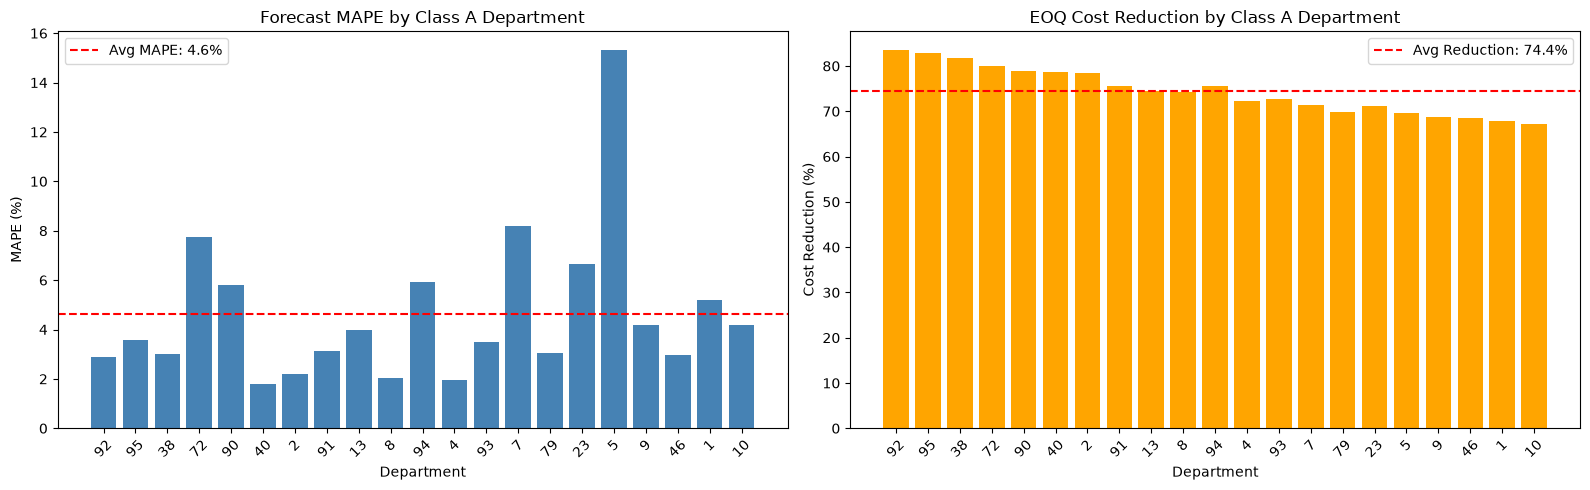

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs('../outputs', exist_ok=True)

merged = results_df.merge(inventory_df[['Dept', 'Cost_Reduction_%']], on='Dept')
merged = merged.dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.bar(range(len(merged)), merged['MAPE_%'], color='steelblue', tick_label=merged['Dept'].astype(str))
ax1.axhline(y=merged['MAPE_%'].mean(), color='red', linestyle='--',
            label=f"Avg MAPE: {merged['MAPE_%'].mean():.1f}%")
ax1.set_title('Forecast MAPE by Class A Department')
ax1.set_xlabel('Department')
ax1.set_ylabel('MAPE (%)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

ax2.bar(range(len(merged)), merged['Cost_Reduction_%'], color='orange', tick_label=merged['Dept'].astype(str))
ax2.axhline(y=merged['Cost_Reduction_%'].mean(), color='red', linestyle='--',
            label=f"Avg Reduction: {merged['Cost_Reduction_%'].mean():.1f}%")
ax2.set_title('EOQ Cost Reduction by Class A Department')
ax2.set_xlabel('Department')
ax2.set_ylabel('Cost Reduction (%)')
ax2.legend()
ax2.tick_params(axis='x', rotation=45)


plt.tight_layout()
plt.savefig('../outputs/multi_sku_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import os
results_df.to_csv('../outputs/multi_sku_forecast_metrics.csv', index=False)
inventory_df.to_csv('../outputs/multi_sku_inventory.csv', index=False)
print("Saved multi_sku_forecast_metrics.csv and multi_sku_inventory.csv")

Saved multi_sku_forecast_metrics.csv and multi_sku_inventory.csv
